# IRIS FLOWER CLASSIFICATION.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load Iris Dataset
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
# Convert Dataset into DataFrame;
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)


In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Add the column of Species into dataset.
df["species"] = iris.target_names[iris.target]

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# EDA ( Exploratory Data Analysis)

In [7]:
df.shape

(150, 5)

In [8]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
# species Distribution means check the unique values
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# Visualizations

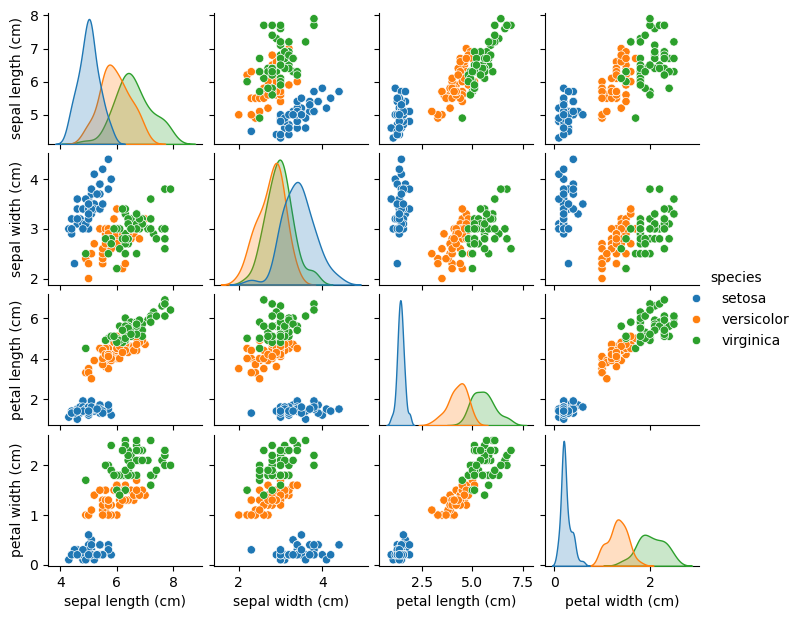

In [11]:
# Pairplot :
g = sns.pairplot(df, hue="species")
g.fig.set_size_inches(8,6)
plt.show()

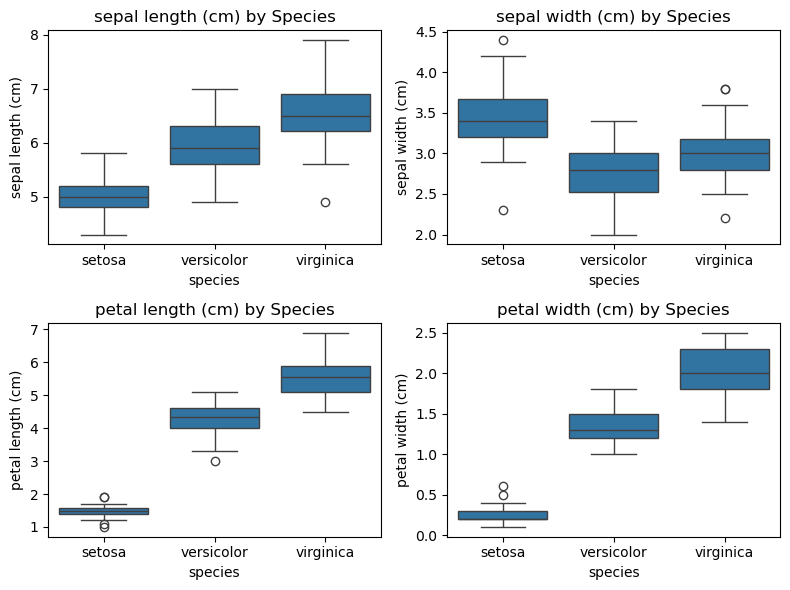

In [30]:
# Create 4 boxplots to compare each Iris feature across different species.

plt.figure(figsize=(8, 6))

features = iris.feature_names

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="species", y=feature, data=df)
    plt.title(f"{feature} by Species")

plt.tight_layout()
plt.show()

# Feature Selection
### Based on the visualizations, petal length and petal width appear to be the most discriminative 
### features because their distributions show clear separation among the iris species.

# TRAIN TEST SPLIT

In [13]:
X = df[iris.feature_names]
y = df["species"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression;

In [15]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# KNN ( K-Nearest Neighbors ) 

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [17]:
# Model Evaluation

In [18]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [19]:
# Logistic Regression accuracy 

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 1.0


In [20]:
# KNN accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 1.0


# Classification Report.

In [21]:
# Logistic Regression.
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
# KNN accuracy. 
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Confusion Matrix for Logistic Regression.

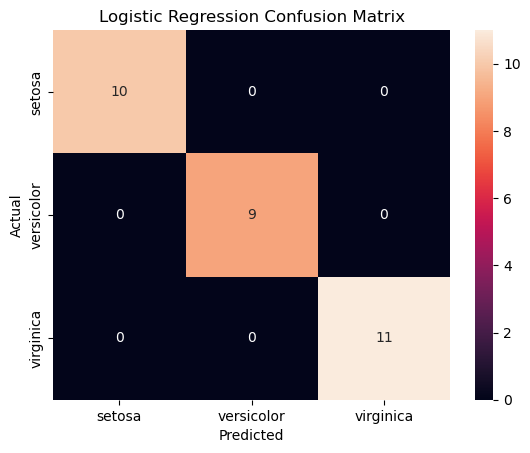

In [23]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Confusion Matrix for KNN 

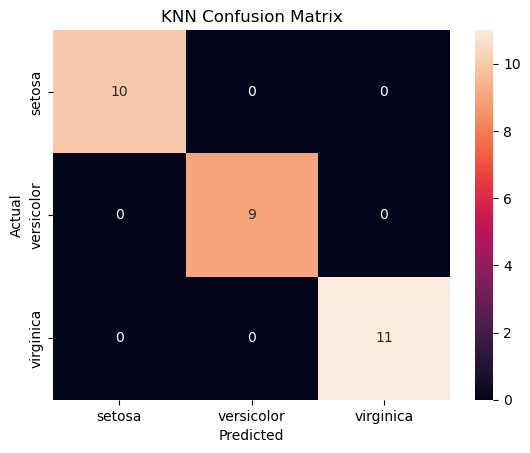

In [24]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

# Compare Models

In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [accuracy_lr, accuracy_knn]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0


# Declare Best Model

In [26]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

best_model

Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object

In [27]:
## Best Performing Model
# Based on the test accuracy, the model with the highest accuracy is selected as the best-performing 
# model for this Iris flower classification task.

# Conclusion

### The Iris Flower Classification project successfully classified iris flowers into Setosa, Versicolor 
### and Virginica using machine learning.

### Exploratory data analysis and visualizations showed that petal-related features provide strong separation 
### between the species. Two classification models, Logistic Regression and K-Nearest Neighbors, were trained 
### and evaluated using accuracy, confusion matrix, precision, recall, and F1-score.

### The model with the highest test accuracy was selected as the best-performing model.